# Complexity and Sensitivity Analysis

**Author:** Daniel González Espinosa

**Year:** 2026

**Binomial Tree Project**

---

## Chapter 1 - Stochastic Calculus for Finance I: The Binomial Asset Pricing Model - Steven E. Shreve


### 1. Environment Setup

We prepare the workspace by importing the standard mathematical libraries and the fundamental classes from our local library.

The pricing engine we will test (`ReducedStateEngine`) implements state compression through node recombination. This, combined with a pure polymorphic design for the options (`EuropeanCall`, `LookbackOption`), will allow us to validate Shreve's no-arbitrage and price sensitivity principles while bypassing algorithmic combinatorial explosion.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

from src.binomial_pricer.lattice import RecombiningLattice
from src.binomial_pricer.equity_model import BinomialStockModel
from src.binomial_pricer.payoffs import EuropeanCall, LookbackOption
from src.binomial_pricer.engines import ReducedStateEngine

print("✅ Environment successfully configured.")
print("✅ Binomial pricing classes imported successfully.")

✅ Environment successfully configured.
✅ Binomial pricing classes imported successfully.


### 2. Validation Against Shreve's Worked Example (Example 1.2.4)

Before exploring the model with generic parameters, we ground the engine in the
exact numerical example Shreve works through by hand in the book: $S_0=4$, $u=2$,
$d=0.5$, $r=0.25$, over three periods, pricing a lookback option. The book derives
$V_0=1.376$ step by step across Examples 1.2.4 and 1.3.2 — reproducing it here with
our own `ReducedStateEngine` is a direct check that the engine faithfully implements
the theory it claims to, not just a plausible-looking price.

In [3]:
shreve_model = BinomialStockModel(s0=4.0, u=2.0, d=0.5, r=0.25)
shreve_lookback = LookbackOption()

shreve_result = ReducedStateEngine().price(model=shreve_model, payoff=shreve_lookback, n_periods=3)

print("=== Reproducing Shreve, Example 1.2.4 / 1.3.2 (Lookback Option) ===")
print(f"V0 computed      : {shreve_result.v0:.4f}")
print(f"V0 in Shreve     : 1.3760")
print(f"Delta0 computed  : {shreve_result.delta0:.4f}")
print(f"Delta0 in Shreve : 0.1733")

assert abs(shreve_result.v0 - 1.376) < 1e-3, "Mismatch against Shreve's own worked example!"
print("\n✅ Engine output matches the book exactly.")

=== Reproducing Shreve, Example 1.2.4 / 1.3.2 (Lookback Option) ===
V0 computed      : 1.3760
V0 in Shreve     : 1.3760
Delta0 computed  : 0.1733
Delta0 in Shreve : 0.1733

✅ Engine output matches the book exactly.


### 3. No-Arbitrage Condition (Ref: Shreve Exercise 1.1)

The first pillar of the binomial model is to ensure that the mathematical configuration of the market does not allow for "riskless profits," that is, it excludes arbitrage. For a model with an up factor $u$, a down factor $d$, and a risk-free interest rate $r$, the fundamental pricing theorem strictly requires that

$$0 < d < 1+r < u.$$

If we violate these analytical boundaries, the market structure collapses financially:

* **If $d \geq 1+r$:** Arbitrage exists by borrowing money from the bank at rate $r$ to invest it entirely in the stock, guaranteeing a net profit.
* **If $u \leq 1+r$:** Arbitrage exists by short-selling the stock to deposit the capital in the bank at rate $r$.

Below, we computationally visualize the valid parameter space for a rate $r$ of 5%.

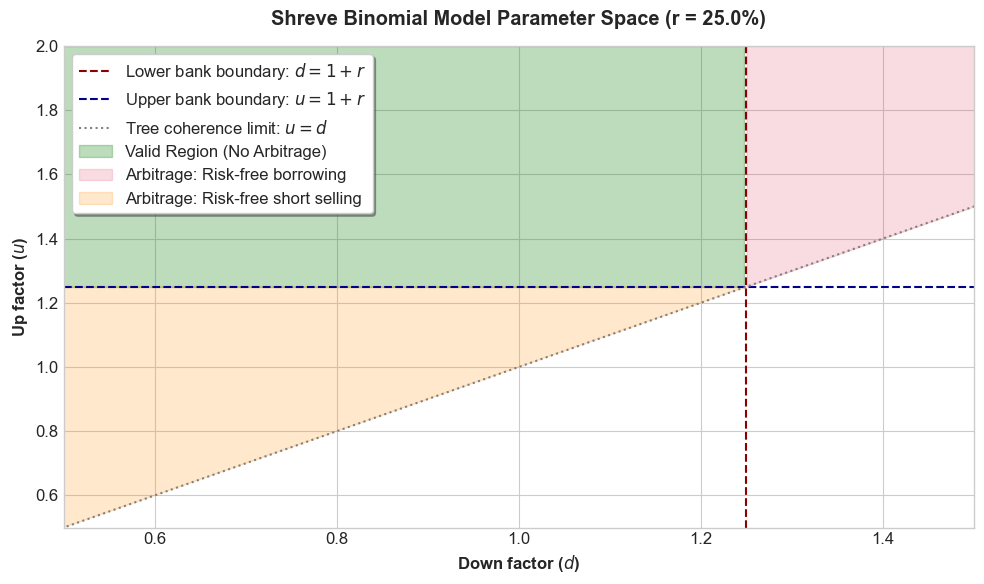

Architecture stress test (Arbitrage Boundaries):
✅ Successful arbitrage block: Arbitrage condition violated: d (1.3) >= 1+r (1.25). 


In [4]:
r = 0.25
risk_free_threshold = 1 + r

d_values = np.linspace(0.1, 1.5, 500)
u_max = 2.0

fig, ax = plt.subplots()

ax.axvline(x=risk_free_threshold, color='darkred', linestyle='--',
label=r'Lower bank boundary: $d = 1+r$')
ax.axhline(y=risk_free_threshold, color='darkblue', linestyle='--',
label=r'Upper bank boundary: $u = 1+r$')
ax.plot([0.1, u_max], [0.1, u_max], color='gray', linestyle=':',
label=r'Tree coherence limit: $u = d$')

ax.fill_between(d_values, risk_free_threshold, u_max,
where=(d_values < risk_free_threshold),
color='forestgreen', alpha=0.3,
label='Valid Region (No Arbitrage)')

ax.fill_between(d_values, d_values, u_max,
where=(d_values >= risk_free_threshold),
color='crimson', alpha=0.15,
label='Arbitrage: Risk-free borrowing')

ax.fill_between(d_values, d_values, risk_free_threshold,
where=(d_values < risk_free_threshold),
color='darkorange', alpha=0.2,
label='Arbitrage: Risk-free short selling')

ax.set_xlim(0.5, 1.5)
ax.set_ylim(0.5, 2.0)
ax.set_xlabel('Down factor ($d$)', fontweight='bold')
ax.set_ylabel('Up factor ($u$)', fontweight='bold')
ax.set_title(f'Shreve Binomial Model Parameter Space (r = {r*100}%)',
fontweight='bold', pad=15)
ax.legend(loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

print("Architecture stress test (Arbitrage Boundaries):")

try:
    invalid_model = BinomialStockModel(s0=4, u=2.0, d=1.30, r=0.25)
except ValueError as e:
    print(f"✅ Successful arbitrage block: {e}")

### 4. The Risk-Neutral Probability Measure ($\tilde{p}$)

The core of Shreve's pricing theorem lies in the construction of a risk-neutral probability measure ($\tilde{p}$).

The fundamental equation for the probability of an upward trajectory in the binomial model is

$$\tilde{p} = \frac{1+r-d}{u-d}.$$

It is crucial to observe that the historical or real probability of the market going up ($p$) does not appear in this formula. The price of a derivative does not depend on our expectations about the market direction, but solely on the no-arbitrage structure dictated by $u$, $d$, and $r$.

Next, we fix the volatility of the underlying asset (through $u$ and $d$) and evaluate how $\tilde{p}$ evolves against variations in the interest rate $r$. To maintain mathematical consistency, $r$ will vary strictly within the no-arbitrage limits ($d < 1+r < u$).

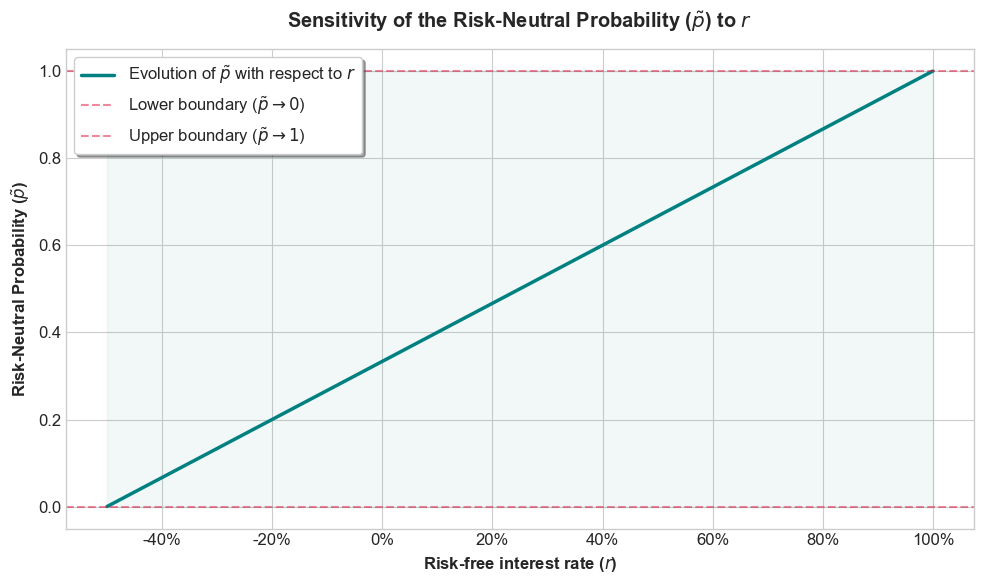

In [5]:
u = 2.00
d = 0.50

r_min = d - 1
r_max = u - 1

epsilon = 0.001
r_values = np.linspace(r_min + epsilon, r_max - epsilon, 200)


p_tilde_values = []
for r_val in r_values:
    test_model = BinomialStockModel(s0=100.0, u=u, d=d, r=r_val)
    
    p_tilde, q_tilde = test_model.risk_neutral_prob
    p_tilde_values.append(p_tilde)

fig, ax = plt.subplots()

ax.plot(r_values, p_tilde_values, color='teal', linewidth=2.5, 
        label=r'Evolution of $\tilde{p}$ with respect to $r$')

ax.axhline(y=0, color='crimson', linestyle='--', alpha=0.5, 
           label=r'Lower boundary ($\tilde{p} \to 0$)')
ax.axhline(y=1, color='crimson', linestyle='--', alpha=0.5, 
           label=r'Upper boundary ($\tilde{p} \to 1$)')

ax.fill_between(r_values, 0, 1, color='teal', alpha=0.05)

ax.set_title(r'Sensitivity of the Risk-Neutral Probability ($\tilde{p}$) to $r$', 
             fontweight='bold', pad=15)
ax.set_xlabel('Risk-free interest rate ($r$)', fontweight='bold')
ax.set_ylabel(r'Risk-Neutral Probability ($\tilde{p}$)', fontweight='bold')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

ax.legend(loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

### 5. Price Sensitivity and Delta Hedging ($\Delta$)

Having demonstrated the consistency of the theoretical boundaries (no-arbitrage and the risk-neutral measure), we proceed to instantiate the core architecture of our `binomial_pricer` library.

According to Shreve's fundamental pricing theorem, the price of a derivative $V_0$ is determined by calculating the discounted expected value under the measure $\tilde{p}$. Simultaneously, the model allows us to calculate the exact position in the underlying asset $\Delta_0$ that forms the replicating portfolio and neutralizes market risk. The Delta sensitivity at the initial node is defined by the discrete derivative

$$\Delta_0 = \frac{V_1(H) - V_1(T)}{S_1(H) - S_1(T)}.$$

We couple `BinomialStockModel` with `ReducedStateEngine` to price a family of `EuropeanCall` options across a spectrum of strike prices ($K$). We will analyze the option's transition from a highly favorable exercise state to an unfavorable exercise state, evaluating how the price decays and how its initial hedge ratio adjusts.

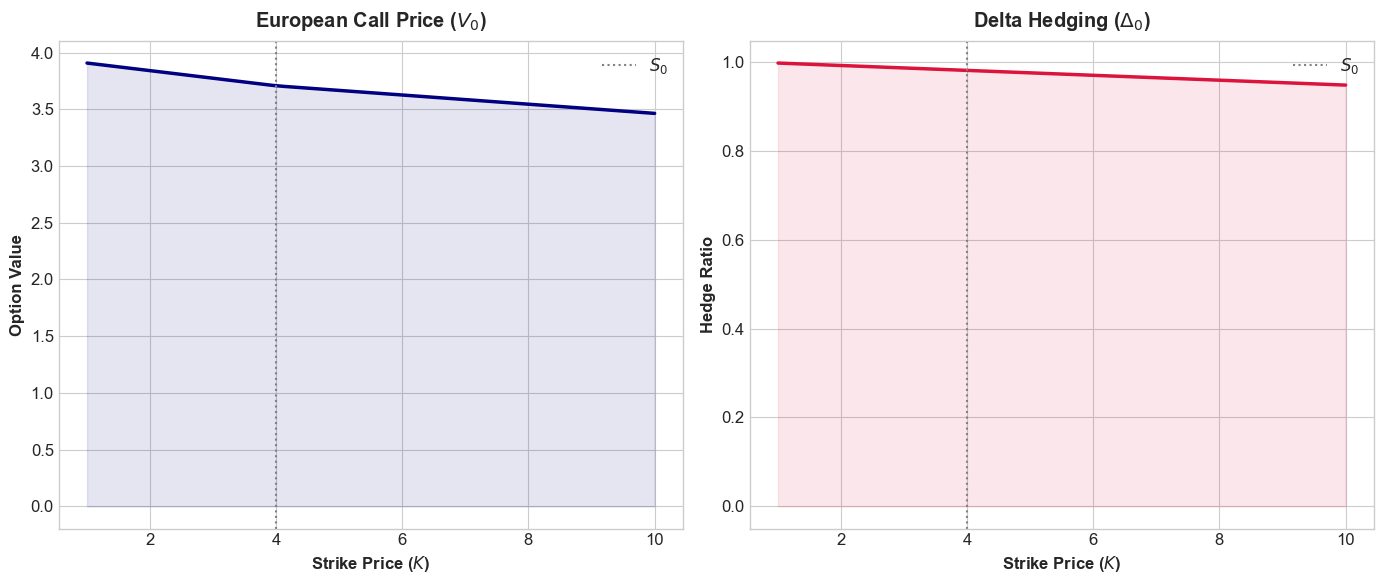

In [7]:
s0 = 4.00 
u = 2.00  
d = 0.50   
r = 0.25    
N = 10       

stock_model = BinomialStockModel(s0, u, d, r)

pricing_engine = ReducedStateEngine()

strikes = np.linspace(1.0, 10.0, 50)
prices_V0 = []
deltas_0 = []

for K in strikes:

    european_call = EuropeanCall(strike=K)

    result = pricing_engine.price(model=stock_model, payoff=european_call, n_periods=N)
    
    prices_V0.append(result.v0)
    deltas_0.append(result.delta0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(strikes, prices_V0, color='navy', linewidth=2.5)
ax1.axvline(x=s0, color='gray', linestyle=':', label='$S_0$')
ax1.set_title(r'European Call Price ($V_0$)', fontweight='bold', pad=10)
ax1.set_xlabel('Strike Price ($K$)', fontweight='bold')
ax1.set_ylabel('Option Value', fontweight='bold')
ax1.fill_between(strikes, prices_V0, color='navy', alpha=0.1)
ax1.legend()

ax2.plot(strikes, deltas_0, color='crimson', linewidth=2.5)
ax2.axvline(x=s0, color='gray', linestyle=':', label='$S_0$')
ax2.set_title(r'Delta Hedging ($\Delta_0$)', fontweight='bold', pad=10)
ax2.set_xlabel('Strike Price ($K$)', fontweight='bold')
ax2.set_ylabel('Hedge Ratio', fontweight='bold')
ax2.fill_between(strikes, deltas_0, color='crimson', alpha=0.1)
ax2.legend()

plt.tight_layout()
plt.show()

### 6. The Path Challenge: Lookback vs. Asian Options

When introducing path-dependent options, the risk-neutral pricing principle requires expanding our state space. It is no longer enough to know the current price of the underlying ($S_n$); we need an additional state variable, $m$, that captures the relevant historical information of the path.

This project defines this transition through the abstract interface `PathDependentPayoff`, delegating to the derived class the definition of the methods `initial_aggregate()`, `update_aggregate()`, and `terminal_value()`. However, the nature of $m$ dictates whether the binomial tree is computationally tractable:

1. **Lookback Option:**
For a Lookback option, the state variable is the historical maximum: $M_n = \max_{0 \le i \le n} S_i$. In a tree where the up and down factors are constant ($u, d$), the price $S_n$ takes discrete values on a grid (lattice). Consequently, multiple paths that converge to the same price $S_n$ also share the same maximum $M_n$. This convergence allows our `ReducedStateEngine` to collapse redundant branches, keeping the algorithmic complexity manageable.
2. **Arithmetic Asian Option (The sum does not recombine):**
For a standard Asian option, the state variable is the accumulated sum: $Y_n = \sum_{i=0}^n S_i$. Unlike the maximum, the exact order in which the ups and downs occur alters the value of the intermediate prices and, therefore, alters the total sum. For example, an (Up, Down) path versus a (Down, Up) path ends at the same $S_2$, but generates a different $Y_2$. Since almost no paths share the same $Y_n$, the tree does not recombine, and the number of states grows at an unsustainable rate of $O(2^N)$.

Below, we validate the tractability of the Lookback option. We take $N=15$ and analyze the generated keys (`StateKey`) to demonstrate the state reduction compared to brute-force enumeration.

In [9]:
s0 = 4.00 
u = 2.00  
d = 0.50   
r = 0.25  
N = 15  

stock_model = BinomialStockModel(s0, u, d, r)
lookback_option = LookbackOption()
reduced_engine = ReducedStateEngine()

lookback_result = reduced_engine.price(model=stock_model, payoff=lookback_option, n_periods=N)

states_n15 = [key for key in lookback_result.value_grid.keys() if key[0] == N]
num_real_states = len(states_n15)
total_paths = 2 ** N

print("=== COMPLEXITY ANALYSIS (N = 15) ===")
print(f"Possible paths (Enumeration $O(2^N)$): {total_paths:,}")
print(f"Unique computed states at n=15:            {num_real_states:,}")
print(f"Algorithm compression factor:           {total_paths / num_real_states:.2f}x\n")

print("=== STATE CONVERGENCE DEMONSTRATION ===")
s_intermediate = s0 * (u**8) * (d**7)

states_same_spot = [
    key for key in states_n15 
    if np.isclose(key[1], s_intermediate)
]

states_same_spot.sort(key=lambda x: x[2])

print(f"Reaching the final price s_15 = {s_intermediate:.2f}, the tree only records the following states:")
for n, s, m in states_same_spot:
    print(f" -> Key: (n={n}, s_n={s:.2f}, Maximum={m:.2f})")

print(f"\nConclusion: Out of the thousands of paths that end at s_15 = {s_intermediate:.2f}, ")
print(f"the history of maximums ('m') converges into only {len(states_same_spot)} distinct variations.")

=== COMPLEXITY ANALYSIS (N = 15) ===
Possible paths (Enumeration $O(2^N)$): 32,768
Unique computed states at n=15:            72
Algorithm compression factor:           455.11x

=== STATE CONVERGENCE DEMONSTRATION ===
Reaching the final price s_15 = 8.00, the tree only records the following states:
 -> Key: (n=15, s_n=8.00, Maximum=8.00)
 -> Key: (n=15, s_n=8.00, Maximum=16.00)
 -> Key: (n=15, s_n=8.00, Maximum=32.00)
 -> Key: (n=15, s_n=8.00, Maximum=64.00)
 -> Key: (n=15, s_n=8.00, Maximum=128.00)
 -> Key: (n=15, s_n=8.00, Maximum=256.00)
 -> Key: (n=15, s_n=8.00, Maximum=512.00)
 -> Key: (n=15, s_n=8.00, Maximum=1024.00)

Conclusion: Out of the thousands of paths that end at s_15 = 8.00, 
the history of maximums ('m') converges into only 8 distinct variations.


### 7. Complexity Analysis: $O(2^N)$ vs $O(N^2)$

Derivative pricing via binomial trees faces an insurmountable computational wall if implemented naively. The `RecombiningLattice` class, through its `enumerate_paths()` method, represents the purely combinatorial approach of the iterative process. For a number of periods $N$, the engine must evaluate $2^N$ possible sequences. This makes the model mathematically correct, but algorithmically intractable for any sufficiently large $N$.

In contrast, the object-oriented architecture of the `ReducedStateEngine` implements the state space compression described by Shreve. By recognizing that in a standard tree the number of distinct price nodes at time $n$ is $n+1$, the space and time complexity for path-independent options (such as the European Call) is reduced to an order of $O(N^2)$.

Below, we will perform a computational performance analysis by subjecting our engine to a stress test with increasing values of $N$ (up to 1000 periods). This will demonstrate how state abstraction transforms an unsolvable exponential problem into a computation that finishes in fractions of a second.

Evaluating ReducedStateEngine (European Call)...

 -> Depth N =   10 | Time: 0.000510 seconds
 -> Depth N =   50 | Time: 0.011077 seconds
 -> Depth N =  100 | Time: 0.042261 seconds
 -> Depth N =  250 | Time: 0.212467 seconds
 -> Depth N =  500 | Time: 0.964750 seconds
 -> Depth N = 1000 | Time: 4.831447 seconds


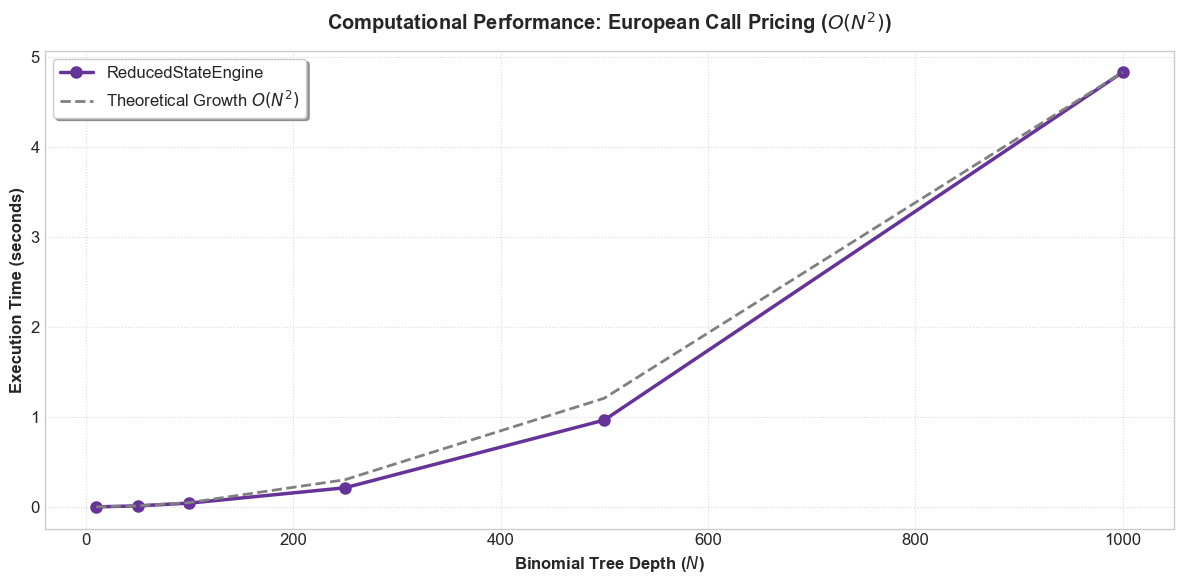

In [10]:
s0 = 4.00 
u = 2.00  
d = 0.50   
r = 0.25 

stock_model = BinomialStockModel(s0, u, d, r)
european_call = EuropeanCall(strike=5.0)
reduced_engine = ReducedStateEngine()

N_values = [10, 50, 100, 250, 500, 1000]
execution_times = []

print("Evaluating ReducedStateEngine (European Call)...\n")

for N in N_values:
    start = time.perf_counter()
    
    _ = reduced_engine.price(model=stock_model, payoff=european_call, n_periods=N)
    
    end = time.perf_counter()
    elapsed_time = end - start
    execution_times.append(elapsed_time)
    
    print(f" -> Depth N = {N:4d} | Time: {elapsed_time:.6f} seconds")

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(N_values, execution_times, marker='o', color='rebeccapurple', 
        linewidth=2.5, markersize=8, label='ReducedStateEngine')

scale_factor = execution_times[-1] / (N_values[-1] ** 2)
theoretical_times_n2 = [scale_factor * (n ** 2) for n in N_values]

ax.plot(N_values, theoretical_times_n2, color='gray', linestyle='--', 
        linewidth=2, label=r'Theoretical Growth $O(N^2)$')

ax.set_title(r'Computational Performance: European Call Pricing ($O(N^2)$)', 
             fontweight='bold', pad=15)
ax.set_xlabel('Binomial Tree Depth ($N$)', fontweight='bold')
ax.set_ylabel('Execution Time (seconds)', fontweight='bold')

ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

## Chapter 2 - Stochastic Calculus for Finance I: Probability Theory on Coin Toss Space - Steven E. Shreve

Having validated the deterministic core of the binomial model — no-arbitrage, risk-neutral pricing, and state-space reduction — we now turn to formalizing the probabilistic machinery that Chapter 1 used implicitly. Chapter 2 of Shreve builds the finite probability space $(\Omega, \mathbb{P})$ underlying the coin-toss model, defines conditional expectation as it updates estimates over time, and uses both to prove that the pricing formulas of Chapter 1 are **martingales** under $\tilde{\mathbb{P}}$ — the deep reason no-arbitrage pricing works at all, not just a computational coincidence.

This section extends `binomial_pricer` with two new modules:
- `probability_space.py` — the `CoinTossSpace` class, encapsulating $\Omega_N$, its probability measure, distribution, expectation, and conditional expectation (Sections 2.1–2.3).
- `stochastic_properties.py` — `is_martingale`, `is_submartingale`, `is_supermartingale`, and `is_markov`: computational validators for the properties Shreve proves by hand (Sections 2.4–2.5).

In [12]:
from itertools import product

from src.binomial_pricer.probability_space import CoinTossSpace
from src.binomial_pricer.stochastic_properties import is_martingale, is_submartingale, is_supermartingale, is_markov
from src.binomial_pricer.engines import PricingEngine

print("✅ Chapter 2 probability and stochastic-properties classes imported successfully.")

✅ Chapter 2 probability and stochastic-properties classes imported successfully.


### 8. The Probability Space $\Omega_N$: Actual vs. Risk-Neutral Measure

Chapter 1 already used a probability measure implicitly — $\tilde{p}$ appears throughout the pricing formulas — but never defined $\Omega$ or $\mathbb{P}$ as objects in their own right. Section 2.1 does exactly that: $\Omega_N$ is the finite set of all coin-toss sequences of length $N$, and $\mathbb{P}(\omega) = p^{\#H(\omega)}q^{\#T(\omega)}$ assigns each path a probability (Eq. 2.1.2 for the enumerated case, generalized in Eq. 2.3.6).

Crucially, this $p$ need not be the risk-neutral $\tilde{p}$ from Chapter 1 — it can be the *actual* (real-world, subjective) probability of an up-move. Exercise 2.2 asks exactly this: fix the tree ($S_0=4, u=2, d=0.5$), and compare the distribution and expectation of $S_3$ under $\tilde{p}=0.5$ against the actual $p=2/3$.

The support of $S_3$ (the set of prices it can reach) is identical under both measures — it only depends on $u, d, N$. What changes is how much probability mass sits on each value, and therefore the mean growth rate.

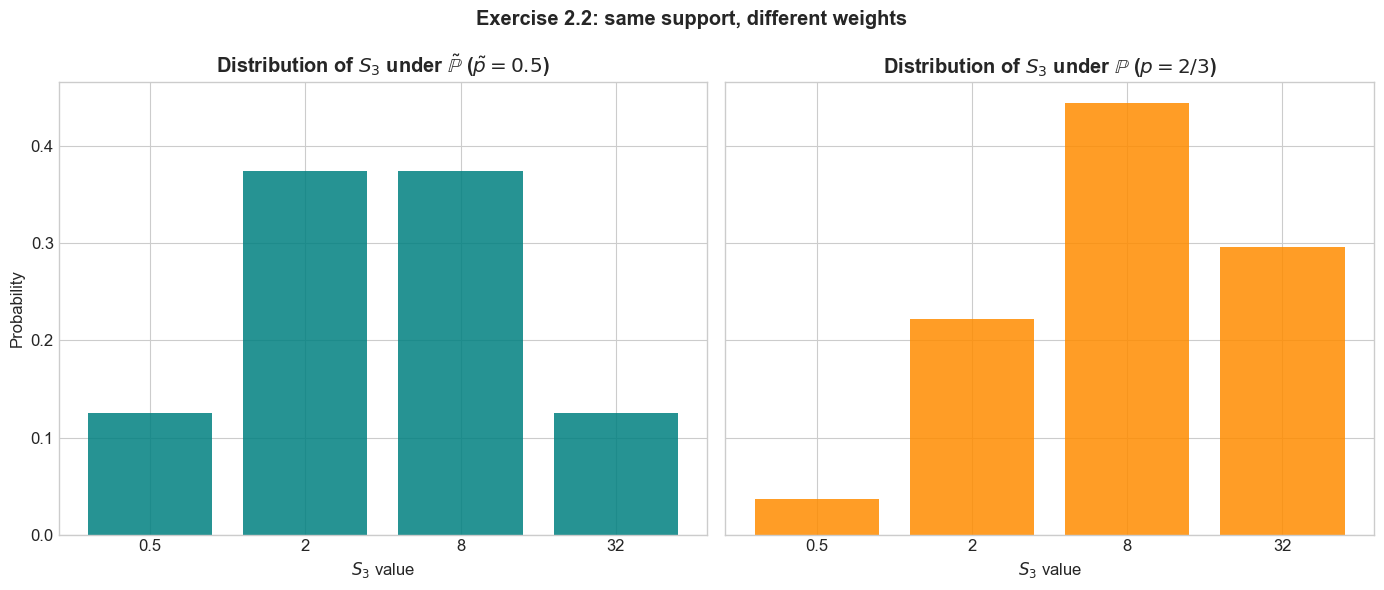

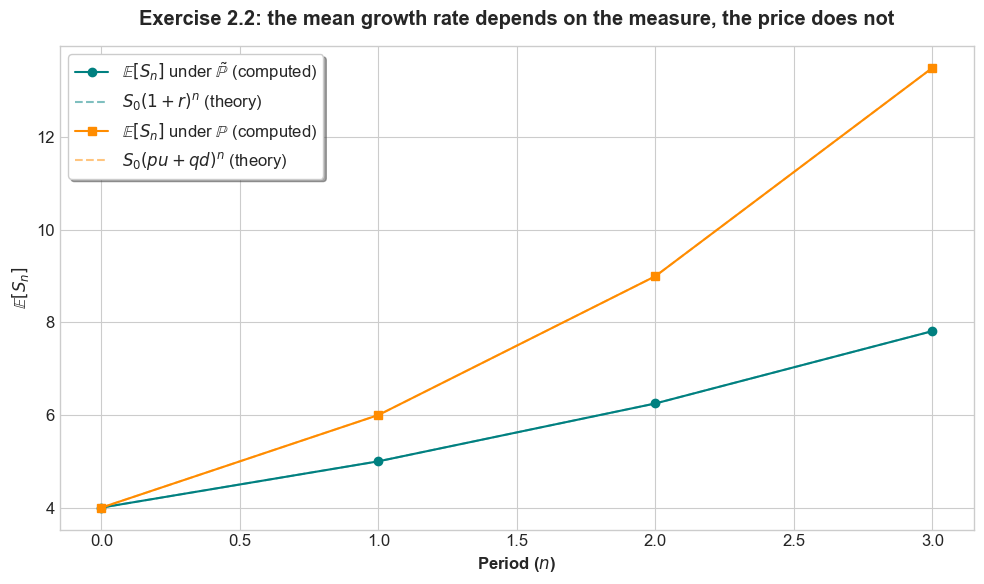

Risk-neutral mean growth per period: 1.2500   (= 1+r,   Eq. 2.3.2 by construction)
Actual mean growth per period:       1.5000   (= pu + qd, the real-world drift)


In [13]:
N = 3
S0, u, d, r = 4.0, 2.0, 0.5, 0.25
stock_model = BinomialStockModel(s0=S0, u=u, d=d, r=r)

p_tilde, _ = stock_model.risk_neutral_prob   # 0.5, per Example 1.1.1
p_real = 2 / 3                                # Exercise 2.2 (iii)

space_rn = CoinTossSpace(n_periods=N, p=p_tilde)
space_real = CoinTossSpace(n_periods=N, p=p_real)

omega = space_rn.get_omega()
S = {n: {w: stock_model.price_path(w)[n] for w in omega} for n in range(N + 1)}

dist_rn_S3 = space_rn.distribution(S[N])
dist_real_S3 = space_real.distribution(S[N])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

values = sorted(dist_rn_S3.keys())
labels = [f"{v:g}" for v in values]

ax1.bar(labels, [dist_rn_S3[v] for v in values], color='teal', alpha=0.85)
ax1.set_title(r'Distribution of $S_3$ under $\tilde{\mathbb{P}}$ ($\tilde{p}=0.5$)', fontweight='bold')
ax1.set_xlabel('$S_3$ value')
ax1.set_ylabel('Probability')

ax2.bar(labels, [dist_real_S3[v] for v in values], color='darkorange', alpha=0.85)
ax2.set_title(r'Distribution of $S_3$ under $\mathbb{P}$ ($p=2/3$)', fontweight='bold')
ax2.set_xlabel('$S_3$ value')

plt.suptitle('Exercise 2.2: same support, different weights', fontweight='bold')
plt.tight_layout()
plt.show()

# --- E[S_n] growth: price target is identical, mean growth rate is not ---
mean_rn = [space_rn.expectation(S[n]) for n in range(N + 1)]
mean_real = [space_real.expectation(S[n]) for n in range(N + 1)]

theoretical_rn = [S0 * (1 + r) ** n for n in range(N + 1)]
mean_growth_real = p_real * u + (1 - p_real) * d
theoretical_real = [S0 * mean_growth_real ** n for n in range(N + 1)]

fig, ax = plt.subplots()
ax.plot(range(N + 1), mean_rn, 'o-', color='teal', label=r'$\mathbb{E}[S_n]$ under $\tilde{\mathbb{P}}$ (computed)')
ax.plot(range(N + 1), theoretical_rn, '--', color='teal', alpha=0.5, label=r'$S_0(1+r)^n$ (theory)')
ax.plot(range(N + 1), mean_real, 's-', color='darkorange', label=r'$\mathbb{E}[S_n]$ under $\mathbb{P}$ (computed)')
ax.plot(range(N + 1), theoretical_real, '--', color='darkorange', alpha=0.5, label=r'$S_0(pu+qd)^n$ (theory)')

ax.set_title('Exercise 2.2: the mean growth rate depends on the measure, the price does not', fontweight='bold', pad=15)
ax.set_xlabel('Period ($n$)', fontweight='bold')
ax.set_ylabel(r'$\mathbb{E}[S_n]$', fontweight='bold')
ax.legend(loc='upper left', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

print(f"Risk-neutral mean growth per period: {1 + r:.4f}   (= 1+r,   Eq. 2.3.2 by construction)")
print(f"Actual mean growth per period:       {mean_growth_real:.4f}   (= pu + qd, the real-world drift)")

### 9. Conditional Expectation in Action: Confirming the Martingale Property

Theorem 2.4.4 states that under $\tilde{\mathbb{P}}$, the discounted stock price $S_n/(1+r)^n$ is a martingale: its conditional expectation one step ahead always equals its current value. Theorem 2.4.5 extends this to the discounted wealth process of *any* self-financing replicating portfolio — which is precisely what `PricingEngine`'s `delta_grid` builds, one node at a time, without ever invoking the word "martingale."

We reconstruct both processes explicitly from the engine's own output for the `EuropeanCall` already priced in Section 5, and hand them to `is_martingale` — turning a property Shreve proves algebraically into a property we can check computationally on our own pricing engine.

Discounted stock price is a martingale under P̃: True
Discounted self-financing wealth is a martingale under P̃: True


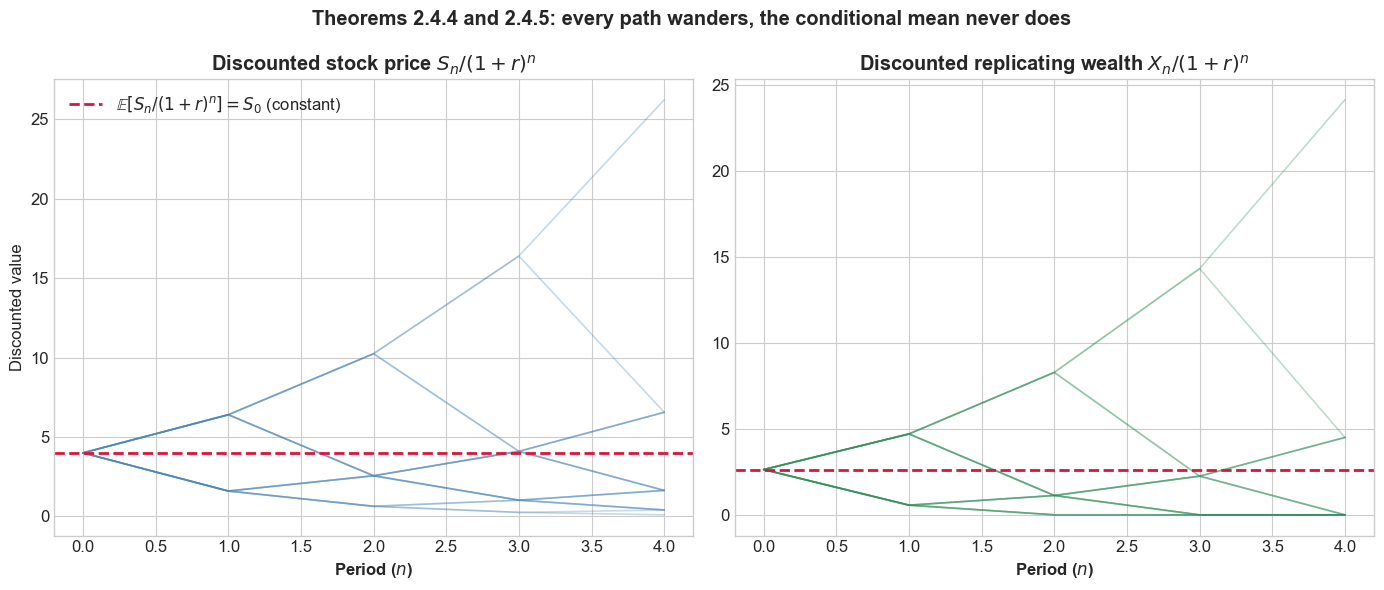


Root-node check (Theorem 2.4.4): S_0 = 4.0000   vs.   E_0[S_1]/(1+r) = 4.0000


In [14]:
N = 4
K = 5.0
call_test = EuropeanCall(strike=K)
result = PricingEngine().price(model=stock_model, payoff=call_test, n_periods=N)

p_tilde, q_tilde = stock_model.risk_neutral_prob
space = CoinTossSpace(n_periods=N, p=p_tilde)

# --- Discounted stock price process: S_n / (1+r)^n  (Theorem 2.4.4) ---
discounted_S = []
for n in range(N + 1):
    prefixes = [""] if n == 0 else ["".join(seq) for seq in product("HT", repeat=n)]
    discounted_S.append({w: stock_model.price_path(w)[-1] / ((1 + r) ** n) for w in prefixes})

print("Discounted stock price is a martingale under P̃:", is_martingale(space, discounted_S))

# --- Discounted self-financing wealth process: X_n / (1+r)^n  (Theorem 2.4.5, Eq. 2.4.6) ---
X = [{"": result.v0}]
for n in range(1, N + 1):
    prefixes = ["".join(seq) for seq in product("HT", repeat=n)]
    layer = {}
    for w in prefixes:
        prev = w[:-1]
        delta_n = result.delta_grid[prev]
        X_prev = X[n - 1][prev]
        S_prev = stock_model.price_path(prev)[-1] if prev else S0
        S_curr = stock_model.price_path(w)[-1]
        layer[w] = delta_n * S_curr + (1 + r) * (X_prev - delta_n * S_prev)
    X.append(layer)

discounted_X = [{w: v / ((1 + r) ** n) for w, v in layer.items()} for n, layer in enumerate(X)]
print("Discounted self-financing wealth is a martingale under P̃:", is_martingale(space, discounted_X))

# --- Visualize: every discounted path wanders, but never drifts ---
full_paths = ["".join(seq) for seq in product("HT", repeat=N)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

for path in full_paths:
    y = [discounted_S[n][path[:n]] for n in range(N + 1)]
    ax1.plot(range(N + 1), y, color='steelblue', alpha=0.3, linewidth=1.2)
ax1.axhline(y=S0, color='crimson', linestyle='--', linewidth=2, label=r'$\mathbb{E}[S_n/(1+r)^n] = S_0$ (constant)')
ax1.set_title(r'Discounted stock price $S_n/(1+r)^n$', fontweight='bold')
ax1.set_xlabel('Period ($n$)', fontweight='bold')
ax1.set_ylabel('Discounted value')
ax1.legend(loc='upper left')

for path in full_paths:
    y = [discounted_X[n][path[:n]] for n in range(N + 1)]
    ax2.plot(range(N + 1), y, color='seagreen', alpha=0.3, linewidth=1.2)
ax2.axhline(y=result.v0, color='crimson', linestyle='--', linewidth=2, label=r'$\mathbb{E}[X_n/(1+r)^n] = X_0 = V_0$ (constant)')
ax2.set_title(r'Discounted replicating wealth $X_n/(1+r)^n$', fontweight='bold')
ax2.set_xlabel('Period ($n$)', fontweight='bold')

plt.suptitle('Theorems 2.4.4 and 2.4.5: every path wanders, the conditional mean never does', fontweight='bold')
plt.tight_layout()
plt.show()

# --- Make the equality concrete at the root node ---
S1_H, S1_T = stock_model.s1_h, stock_model.s1_t
lhs = S0
rhs = (p_tilde * S1_H + q_tilde * S1_T) / (1 + r)
print(f"\nRoot-node check (Theorem 2.4.4): S_0 = {lhs:.4f}   vs.   E_0[S_1]/(1+r) = {rhs:.4f}")

### 10. Convexity and Submartingales: Exercise 2.3 in Motion

Theorem 2.3.2(v) — the conditional Jensen's inequality — is usually stated as a single static formula: $\mathbb{E}_n[\varphi(X)] \ge \varphi(\mathbb{E}_n[X])$ for convex $\varphi$. Exercise 2.3 turns this into a dynamic claim about processes: if $M_n$ is a martingale and $\varphi$ is convex, then $\varphi(M_n)$ is a **submartingale** — its conditional mean can only drift upward, never stay flat or fall.

We use the symmetric random walk $M_n$ from Exercise 2.4 ($M_n = \sum_{j=1}^n X_j$, $X_j = \pm 1$ with equal probability) — a pure martingale by construction — and apply the convex function $\varphi(x) = x^2$. `is_martingale` and `is_submartingale` let us confirm computationally what Jensen guarantees analytically: $\mathbb{E}[M_n]$ stays flat at 0, while $\mathbb{E}[M_n^2]$ grows strictly with $n$ (in fact $\mathbb{E}[M_n^2] = n$ exactly, since $M_n$ is a sum of $n$ independent $\pm1$ steps).

M_n is a martingale:                  True
phi(M_n) = M_n^2 is a submartingale:  True
phi(M_n) = M_n^2 is NOT a martingale:  True


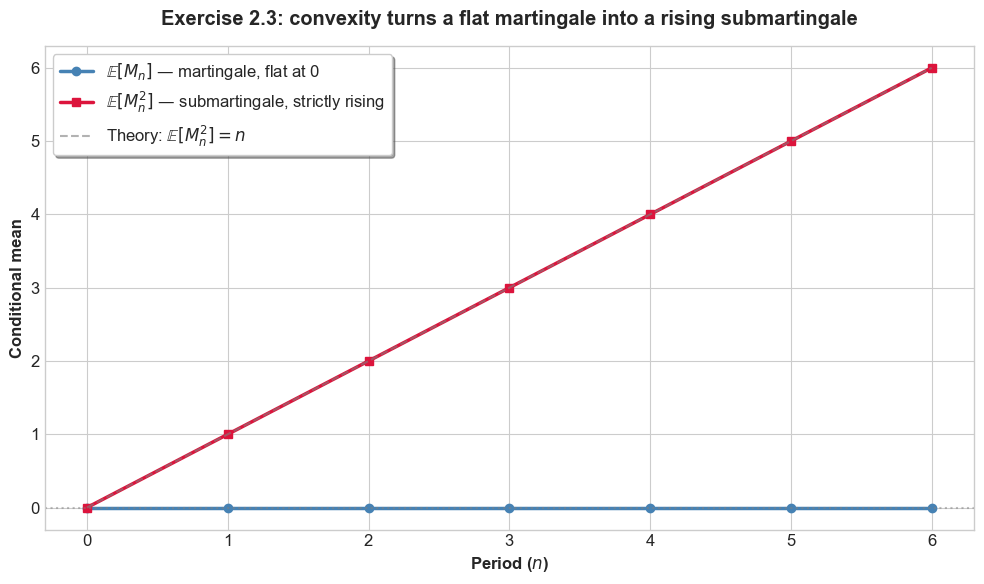

In [15]:
from itertools import product

N = 6
space_rw = CoinTossSpace(n_periods=N, p=0.5)

# Symmetric random walk M_n = sum_{j=1}^n X_j, X_j = +1 if H else -1 (Exercise 2.4)
M = [{"": 0.0}]
for n in range(1, N + 1):
    layer = {}
    for seq in product("HT", repeat=n):
        path = "".join(seq)
        layer[path] = sum(1.0 if c == 'H' else -1.0 for c in path)
    M.append(layer)

# Convex function phi(x) = x^2 applied pointwise (Exercise 2.3)
phi_M = [{w: v ** 2 for w, v in layer.items()} for layer in M]

print("M_n is a martingale:                 ", is_martingale(space_rw, M))
print("phi(M_n) = M_n^2 is a submartingale: ", is_submartingale(space_rw, phi_M))
print("phi(M_n) = M_n^2 is NOT a martingale: ", not is_martingale(space_rw, phi_M))

mean_M = [space_rw.expectation(M[n]) for n in range(N + 1)]
mean_phi_M = [space_rw.expectation(phi_M[n]) for n in range(N + 1)]
theoretical_variance = [float(n) for n in range(N + 1)]  # E[M_n^2] = n exactly

fig, ax = plt.subplots()
ax.plot(range(N + 1), mean_M, 'o-', color='steelblue', linewidth=2.5,
        label=r'$\mathbb{E}[M_n]$ — martingale, flat at 0')
ax.plot(range(N + 1), mean_phi_M, 's-', color='crimson', linewidth=2.5,
        label=r'$\mathbb{E}[M_n^2]$ — submartingale, strictly rising')
ax.plot(range(N + 1), theoretical_variance, '--', color='gray', alpha=0.6,
        label=r'Theory: $\mathbb{E}[M_n^2] = n$')
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)

ax.set_title('Exercise 2.3: convexity turns a flat martingale into a rising submartingale',
             fontweight='bold', pad=15)
ax.set_xlabel('Period ($n$)', fontweight='bold')
ax.set_ylabel('Conditional mean', fontweight='bold')
ax.legend(loc='upper left', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

### 11. When Two Paths Collide: The Markov Counterexample (Example 2.5.4)

Section 1.3 justified state-space reduction empirically: track $(S_n, M_n)$ instead of the full path, and the lookback tree recombines. Section 2.5 explains *why* this is legitimate — $(S_n, M_n)$ satisfies the Markov property (Definition 2.5.5), so a deterministic pricing function $v_n(s, m)$ is guaranteed to exist (Theorem 2.5.8).

But the running maximum $M_n$ *alone* is not enough. Example 2.5.4 gives the exact counterexample: in the model $S_0=4, u=2, d=0.5$ with actual probabilities $p=2/3, q=1/3$, the paths $TH$ and $TT$ both reach $M_2 = 4$ — the *same* state — yet lead to strictly different distributions of $M_3$. We reproduce the book's own numbers below, then visualize the collision directly.

M_n alone is Markov:    False
(S_n, M_n) is Markov:   True

M_2(TH) = 4.0   M_2(TT) = 4.0   -> same state: True
E_2[M_3](TH) = 0.667*8.0 + 0.333*4.0 = 6.6667
E_2[M_3](TT) = 0.667*4.0 + 0.333*4.0 = 4.0000

Same current state, different future expectation -> no function g(M_2) can exist -> not Markov.


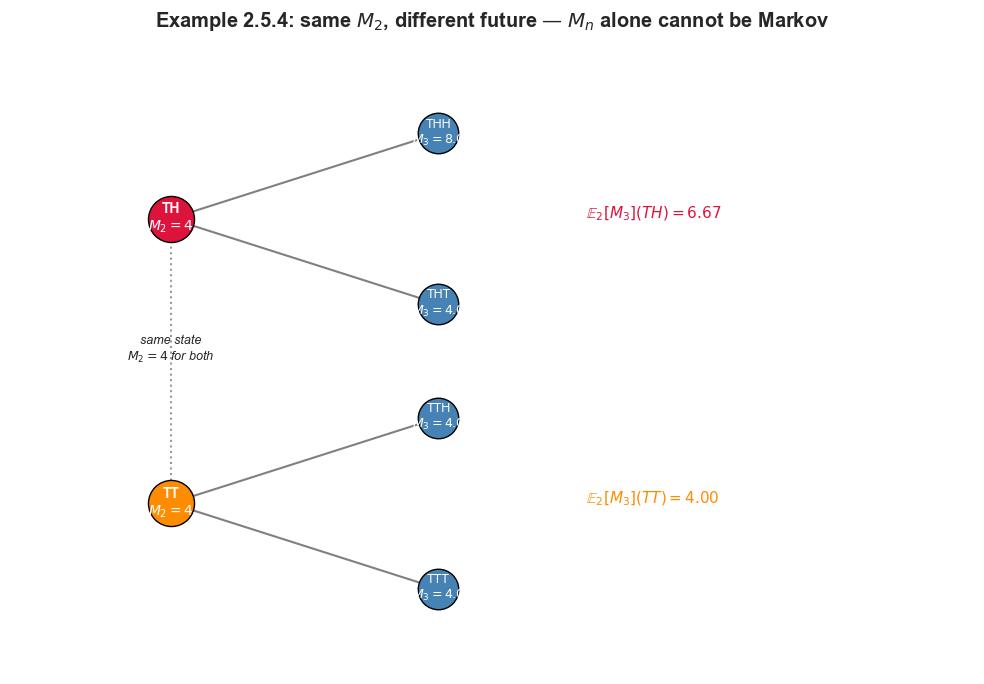

In [16]:
from itertools import product

S0, u, d, r = 4.0, 2.0, 0.5, 0.25
stock_model = BinomialStockModel(s0=S0, u=u, d=d, r=r)
p_actual = 2 / 3
N = 3

space = CoinTossSpace(n_periods=N, p=p_actual)

# --- Build both candidate state processes: M_n (1D) and (S_n, M_n) (2D) ---
process_1d, process_2d = [], []
for n in range(N + 1):
    layer_1d, layer_2d = {}, {}
    prefixes = [""] if n == 0 else ["".join(seq) for seq in product("HT", repeat=n)]
    for w in prefixes:
        prices = stock_model.price_path(w)
        m = max(prices)
        layer_1d[w] = m
        layer_2d[w] = (prices[-1], m)
    process_1d.append(layer_1d)
    process_2d.append(layer_2d)

print("M_n alone is Markov:   ", is_markov(space, process_1d))
print("(S_n, M_n) is Markov:  ", is_markov(space, process_2d))

# --- Reproduce the book's exact numbers for the TH vs. TT collision ---
M2_TH, M2_TT = process_1d[2]["TH"], process_1d[2]["TT"]
M3_THH, M3_THT = process_1d[3]["THH"], process_1d[3]["THT"]
M3_TTH, M3_TTT = process_1d[3]["TTH"], process_1d[3]["TTT"]

p, q = space.p, space.q
E2_M3_TH = p * M3_THH + q * M3_THT
E2_M3_TT = p * M3_TTH + q * M3_TTT

print(f"\nM_2(TH) = {M2_TH:.1f}   M_2(TT) = {M2_TT:.1f}   -> same state: {M2_TH == M2_TT}")
print(f"E_2[M_3](TH) = {p:.3f}*{M3_THH:.1f} + {q:.3f}*{M3_THT:.1f} = {E2_M3_TH:.4f}")
print(f"E_2[M_3](TT) = {p:.3f}*{M3_TTH:.1f} + {q:.3f}*{M3_TTT:.1f} = {E2_M3_TT:.4f}")
print("\nSame current state, different future expectation -> no function g(M_2) can exist -> not Markov.")

# --- Visualize the collision: TH and TT converge, then diverge ---
pos = {
    'TH': (0, 1), 'TT': (0, -1),
    'THH': (1, 1.6), 'THT': (1, 0.4),
    'TTH': (1, -0.4), 'TTT': (1, -1.6),
}
values = {
    'TH': M2_TH, 'TT': M2_TT,
    'THH': M3_THH, 'THT': M3_THT, 'TTH': M3_TTH, 'TTT': M3_TTT,
}

fig, ax = plt.subplots(figsize=(10, 7))

for a, b in [('TH', 'THH'), ('TH', 'THT'), ('TT', 'TTH'), ('TT', 'TTT')]:
    ax.plot([pos[a][0], pos[b][0]], [pos[a][1], pos[b][1]], color='gray', linewidth=1.5, zorder=1)

for node, color in [('TH', 'crimson'), ('TT', 'darkorange')]:
    x, y = pos[node]
    ax.scatter(x, y, s=1100, color=color, zorder=2, edgecolor='black')
    ax.annotate(f"{node}\n$M_2={values[node]:.0f}$", (x, y), ha='center', va='center',
                fontsize=10, fontweight='bold', color='white', zorder=3)

for node in ['THH', 'THT', 'TTH', 'TTT']:
    x, y = pos[node]
    ax.scatter(x, y, s=850, color='steelblue', zorder=2, edgecolor='black')
    ax.annotate(f"{node}\n$M_3={values[node]:.1f}$", (x, y), ha='center', va='center',
                fontsize=9, color='white', zorder=3)

ax.plot([pos['TH'][0], pos['TT'][0]], [pos['TH'][1], pos['TT'][1]],
        linestyle=':', color='black', alpha=0.4, zorder=0)
ax.annotate('same state\n$M_2 = 4$ for both', xy=(0, 0), ha='center', fontsize=9, style='italic')

ax.annotate(rf"$\mathbb{{E}}_2[M_3](TH) = {E2_M3_TH:.2f}$", xy=(1.55, 1.0), ha='left',
            fontsize=11, color='crimson', fontweight='bold')
ax.annotate(rf"$\mathbb{{E}}_2[M_3](TT) = {E2_M3_TT:.2f}$", xy=(1.55, -1.0), ha='left',
            fontsize=11, color='darkorange', fontweight='bold')

ax.set_xlim(-0.6, 3)
ax.set_ylim(-2.2, 2.2)
ax.axis('off')
ax.set_title('Example 2.5.4: same $M_2$, different future — $M_n$ alone cannot be Markov',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 12. Markov ≠ Recombining: Closing the Loop with Chapter 1

Section 1.3 justified state reduction purely empirically: track $(S_n, M_n)$ for the lookback and the tree recombines; track $(S_n, Y_n)$ for the Asian and it doesn't. Section 2.5 tells us *why* the first case is even legitimate — both $(S_n,M_n)$ (Example 2.5.6) and $(S_n,Y_n)$ (Exercise 2.13) **are** valid Markov processes, so Theorem 2.5.8 guarantees a deterministic pricing function $v_n$ exists for both. Markov-ness is necessary for a clean recursive pricing formula to exist at all.

But Theorem 2.5.8 says nothing about *how many* values that function needs to be evaluated at. That's a separate, purely combinatorial question — and it's the one that actually determines whether the algorithm is fast. Below we confirm both states are Markov with `is_markov`, then count the distinct states at each level directly (mirroring `ReducedStateEngine`'s own state-construction logic) to see the two complexity classes side by side.

(S_n, M_n) is Markov (Example 2.5.6):   True
(S_n, Y_n) is Markov (Exercise 2.13):   True


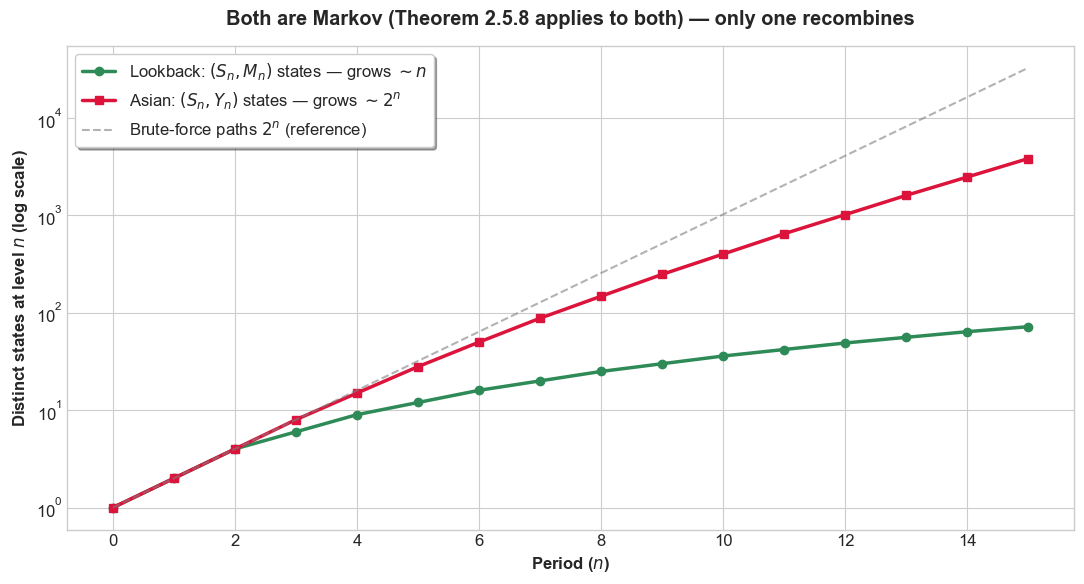


At n=15: Lookback keeps 72 states, Asian needs 3836 (= 2^15, identical to brute force: 32768).


In [18]:
from itertools import product

from src.binomial_pricer.equity_model import BinomialStockModel
from src.binomial_pricer.payoffs import LookbackOption, AsianOption
from src.binomial_pricer.probability_space import CoinTossSpace
from src.binomial_pricer.stochastic_properties import is_markov

S0, u, d, r = 4.0, 2.0, 0.5, 0.25
stock_model = BinomialStockModel(s0=S0, u=u, d=d, r=r)
p_tilde, _ = stock_model.risk_neutral_prob

# --- Part 1: confirm both states ARE Markov (small N, cheap to check exhaustively) ---
N_check = 4
space_check = CoinTossSpace(n_periods=N_check, p=p_tilde)

process_lookback, process_asian = [], []
for n in range(N_check + 1):
    layer_lb, layer_as = {}, {}
    prefixes = [""] if n == 0 else ["".join(seq) for seq in product("HT", repeat=n)]
    for w in prefixes:
        prices = stock_model.price_path(w)
        layer_lb[w] = (prices[-1], max(prices))
        layer_as[w] = (prices[-1], sum(prices))
    process_lookback.append(layer_lb)
    process_asian.append(layer_as)

print("(S_n, M_n) is Markov (Example 2.5.6):  ", is_markov(space_check, process_lookback))
print("(S_n, Y_n) is Markov (Exercise 2.13):  ", is_markov(space_check, process_asian))

# --- Part 2: count distinct states per level, mirroring ReducedStateEngine's own
#     state construction (precomputed u/d powers, never incremental multiplication --
#     see the project's own history of float-drift bugs from s *= u, s *= d chains) ---
def count_states_per_level(model, payoff, n_periods):
    u_powers = [1.0] * (n_periods + 2)
    d_powers = [1.0] * (n_periods + 2)
    for i in range(1, n_periods + 2):
        u_powers[i] = u_powers[i - 1] * model.u
        d_powers[i] = d_powers[i - 1] * model.d

    def get_s(j, n_step):
        return model.s0 * u_powers[j] * d_powers[n_step - j]

    m0 = payoff.initial_aggregate(model.s0)
    states_by_level = {0: {(0, m0)}}
    for n in range(n_periods):
        next_level = set()
        for j, m in states_by_level[n]:
            s_up = get_s(j + 1, n + 1)
            next_level.add((j + 1, payoff.update_aggregate(m, s_up)))
            s_down = get_s(j, n + 1)
            next_level.add((j, payoff.update_aggregate(m, s_down)))
        states_by_level[n + 1] = next_level

    return [len(states_by_level[n]) for n in range(n_periods + 1)]

N_scale = 15
levels = list(range(N_scale + 1))
counts_lookback = count_states_per_level(stock_model, LookbackOption(), N_scale)
counts_asian = count_states_per_level(stock_model, AsianOption(strike=0.0, n_periods=N_scale), N_scale)
counts_brute = [2 ** n for n in levels]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(levels, counts_lookback, 'o-', color='seagreen', linewidth=2.5, label=r'Lookback: $(S_n, M_n)$ states — grows $\sim n$')
ax.plot(levels, counts_asian, 's-', color='crimson', linewidth=2.5, label=r'Asian: $(S_n, Y_n)$ states — grows $\sim 2^n$')
ax.plot(levels, counts_brute, '--', color='gray', alpha=0.6, label=r'Brute-force paths $2^n$ (reference)')

ax.set_yscale('log')
ax.set_title('Both are Markov (Theorem 2.5.8 applies to both) — only one recombines', fontweight='bold', pad=15)
ax.set_xlabel('Period ($n$)', fontweight='bold')
ax.set_ylabel('Distinct states at level $n$ (log scale)', fontweight='bold')
ax.legend(loc='upper left', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

print(f"\nAt n={N_scale}: Lookback keeps {counts_lookback[-1]} states, Asian needs {counts_asian[-1]} "
      f"(= 2^{N_scale}, identical to brute force: {counts_brute[-1]}).")

### 13. Put-Call Parity and the Chooser Option (Exercises 2.11–2.12)

Exercise 2.11 shows that a call, a put, and a forward on the same stock and strike are not independent: $C_n = F_n + P_n$ at every node, for every $n$ — buying a forward and a put replicates a call exactly. Exercise 2.12 builds on this to price a **chooser option**: the right to decide at time $m < N$ whether the contract becomes a call or a put (both struck at $K$, expiring at $N$). Its time-zero price collapses to a put plus an *adjusted-strike* call: $\text{Put}(K, N) + \text{Call}\!\left(\frac{K}{(1+r)^{N-m}}, m\right)$.

We verify parity across a range of strikes, then verify the chooser identity and show it dominates a plain call and a plain put at every strike — it has to, since it embeds optionality on top of both.

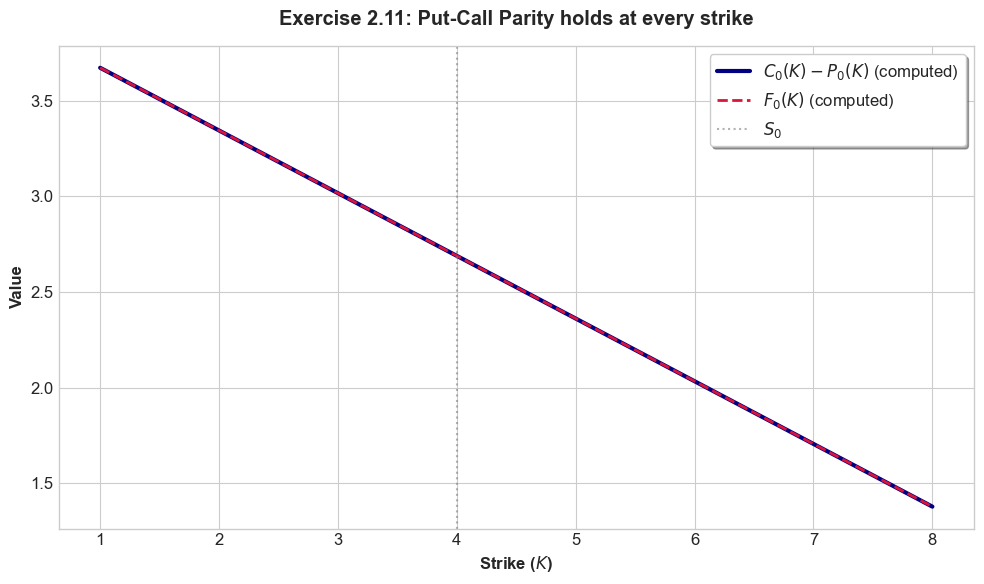

Max |C_0(K) - P_0(K) - F_0(K)| across all strikes: 1.3322676295501878e-15


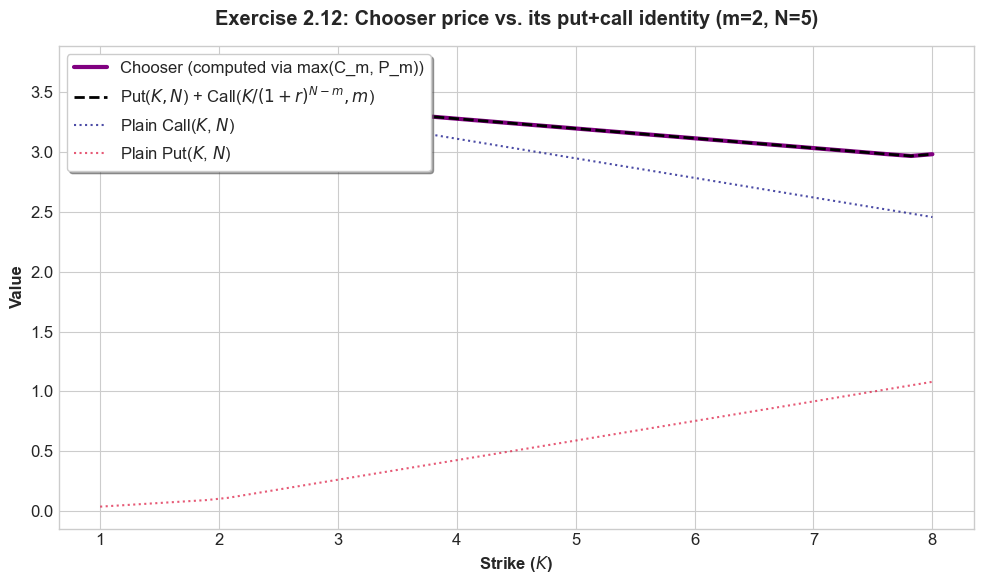

Max |Chooser - (Put + adjusted Call)| across all strikes: 8.881784197001252e-16
Chooser dominates both plain Call and plain Put at every strike: True


In [19]:
from itertools import product

from src.binomial_pricer.equity_model import BinomialStockModel
from src.binomial_pricer.payoffs import EuropeanCall, EuropeanPut, Forward
from src.binomial_pricer.engines import PricingEngine
from src.binomial_pricer.probability_space import CoinTossSpace

S0, u, d, r = 4.0, 2.0, 0.5, 0.25
stock_model = BinomialStockModel(s0=S0, u=u, d=d, r=r)
p_tilde, _ = stock_model.risk_neutral_prob
engine = PricingEngine()

N = 5
strikes = np.linspace(1.0, 8.0, 40)

# --- Part 1: Put-Call-Forward parity across strikes (Exercise 2.11) ---
calls = [engine.price(stock_model, EuropeanCall(strike=K), n_periods=N).v0 for K in strikes]
puts = [engine.price(stock_model, EuropeanPut(strike=K), n_periods=N).v0 for K in strikes]
forwards = [engine.price(stock_model, Forward(delivery_price=K), n_periods=N).v0 for K in strikes]
c_minus_p = [c - p for c, p in zip(calls, puts)]

fig, ax = plt.subplots()
ax.plot(strikes, c_minus_p, color='navy', linewidth=3, label=r'$C_0(K) - P_0(K)$ (computed)')
ax.plot(strikes, forwards, '--', color='crimson', linewidth=2, label=r'$F_0(K)$ (computed)')
ax.axvline(x=S0, color='gray', linestyle=':', alpha=0.6, label='$S_0$')
ax.set_title('Exercise 2.11: Put-Call Parity holds at every strike', fontweight='bold', pad=15)
ax.set_xlabel('Strike ($K$)', fontweight='bold')
ax.set_ylabel('Value', fontweight='bold')
ax.legend(loc='upper right', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

print("Max |C_0(K) - P_0(K) - F_0(K)| across all strikes:", max(abs(a - b) for a, b in zip(c_minus_p, forwards)))

# --- Part 2: Chooser option (Exercise 2.12), priced across the same strikes ---
m = N // 2  # decision time, strictly between 0 and N

def price_chooser(K, N, m, stock_model, engine, p_tilde, r):
    res_call_N = engine.price(stock_model, EuropeanCall(strike=K), n_periods=N)
    res_put_N = engine.price(stock_model, EuropeanPut(strike=K), n_periods=N)

    chooser_m = {}
    for seq in product("HT", repeat=m):
        path = "".join(seq)
        chooser_m[path] = max(res_call_N.value_grid[path], res_put_N.value_grid[path])

    space_m = CoinTossSpace(n_periods=m, p=p_tilde)
    return space_m.expectation(chooser_m) / ((1 + r) ** m), res_call_N.v0, res_put_N.v0

choosers, plain_calls, plain_puts, identity_rhs = [], [], [], []
for K in strikes:
    chooser_0, call_0, put_0 = price_chooser(K, N, m, stock_model, engine, p_tilde, r)
    adjusted_strike = K / ((1 + r) ** (N - m))
    call_m_adjusted = engine.price(stock_model, EuropeanCall(strike=adjusted_strike), n_periods=m).v0

    choosers.append(chooser_0)
    plain_calls.append(call_0)
    plain_puts.append(put_0)
    identity_rhs.append(put_0 + call_m_adjusted)

fig, ax = plt.subplots()
ax.plot(strikes, choosers, color='purple', linewidth=3, label='Chooser (computed via max(C_m, P_m))')
ax.plot(strikes, identity_rhs, '--', color='black', linewidth=2, label=r'Put($K,N$) + Call($K/(1+r)^{N-m}, m$)')
ax.plot(strikes, plain_calls, ':', color='navy', alpha=0.7, label='Plain Call($K$, $N$)')
ax.plot(strikes, plain_puts, ':', color='crimson', alpha=0.7, label='Plain Put($K$, $N$)')

ax.set_title(f'Exercise 2.12: Chooser price vs. its put+call identity (m={m}, N={N})', fontweight='bold', pad=15)
ax.set_xlabel('Strike ($K$)', fontweight='bold')
ax.set_ylabel('Value', fontweight='bold')
ax.legend(loc='upper left', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

print("Max |Chooser - (Put + adjusted Call)| across all strikes:",
      max(abs(a - b) for a, b in zip(choosers, identity_rhs)))
print("Chooser dominates both plain Call and plain Put at every strike:",
      all(ch >= c - 1e-9 and ch >= p - 1e-9 for ch, c, p in zip(choosers, plain_calls, plain_puts)))